DataFrame Sample :
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target target_names  
0       0       setosa  
1       0       setosa  
2       0       setosa  
3       0       setosa  
4       0       setosa  
테스트 데이터 정확도 : 0.97
분류 보고서 :
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
we

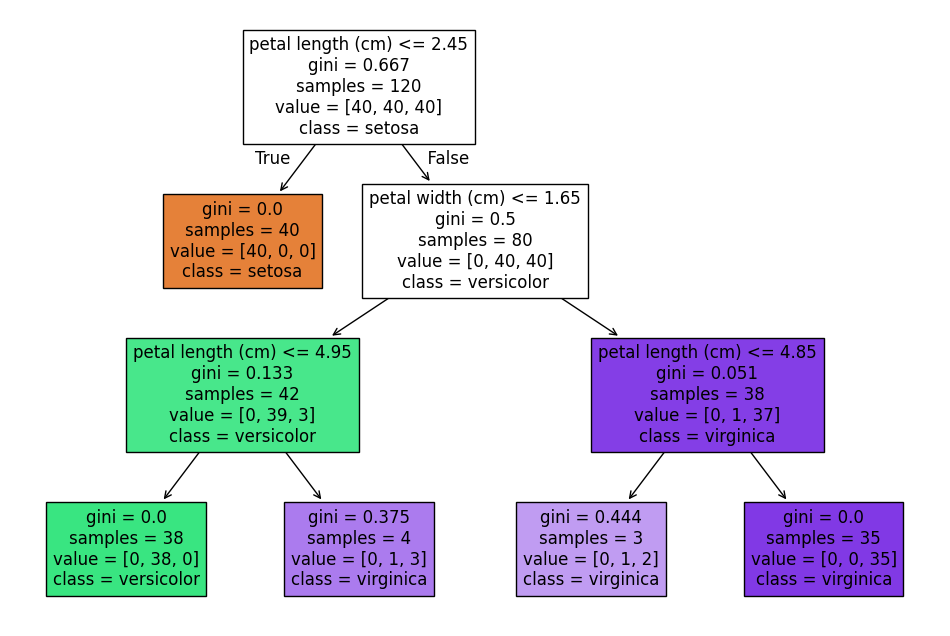

In [1]:
# 붓꽃 (Iris) 품종 : Setosa, Versicolor, Viginica
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import plot_tree # 의사결정 나무의 구조를 그래픽으로 표현
import matplotlib.pyplot as plt

# 데이터 로드
iris = load_iris()
X = iris.data # 특징 (꽃잎, 꽃받침 길이/너비)
y = iris.target # 품종 (0: Setosa, 1: Versicolor, 2: Viginica)
feature_names = iris.feature_names # 특징 이름
target_names = iris.target_names # 품종 이름

# Pandas DataFrame 생성
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['target_names'] = [target_names[i] for i in y] # target 이름 추가

# 데이터프레임 출력 (처음 5행)
print("DataFrame Sample :")
print(df.head())

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 의사결정 나무 모델 생성
clf = DecisionTreeClassifier(random_state=42, max_depth=3) # max_depth : 트리의 최대 깊이 제한
clf.fit(X_train, y_train) # 훈련 데이터로 모델 학습

# 테스트 데이터로 예측
y_pred = clf.predict(X_test)

# 정확도 평가
accuracy = accuracy_score(y_test, y_pred)
print(f"테스트 데이터 정확도 : {accuracy:.2f}")

# 분류 보고서
print("분류 보고서 :")
print(classification_report(y_test, y_pred, target_names=target_names))

# 의사결정 트리 시각화
plt.figure(figsize=(12,8))
plot_tree(clf, filled=True, feature_names=feature_names, class_names=target_names)
plt.show()



DataFrame Sample :
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target target_names  
0       0       setosa  
1       0       setosa  
2       0       setosa  
3       0       setosa  
4       0       setosa  
최적의 파라미터 : {'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
테스트 데이터 정확도 : 0.9666666666666667
분류 보고서 :
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10



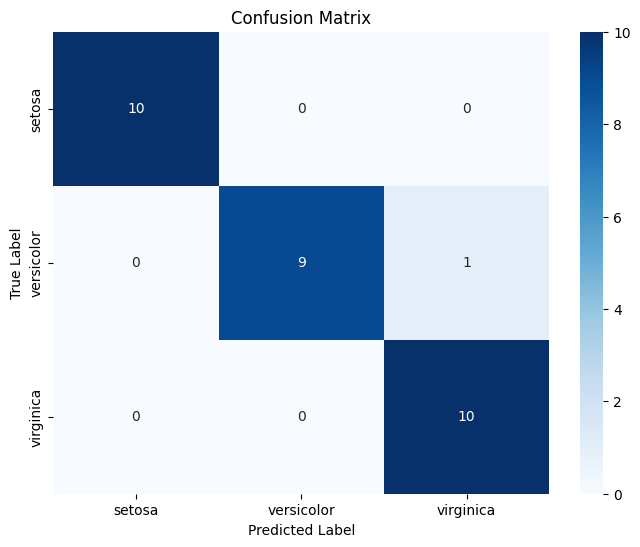

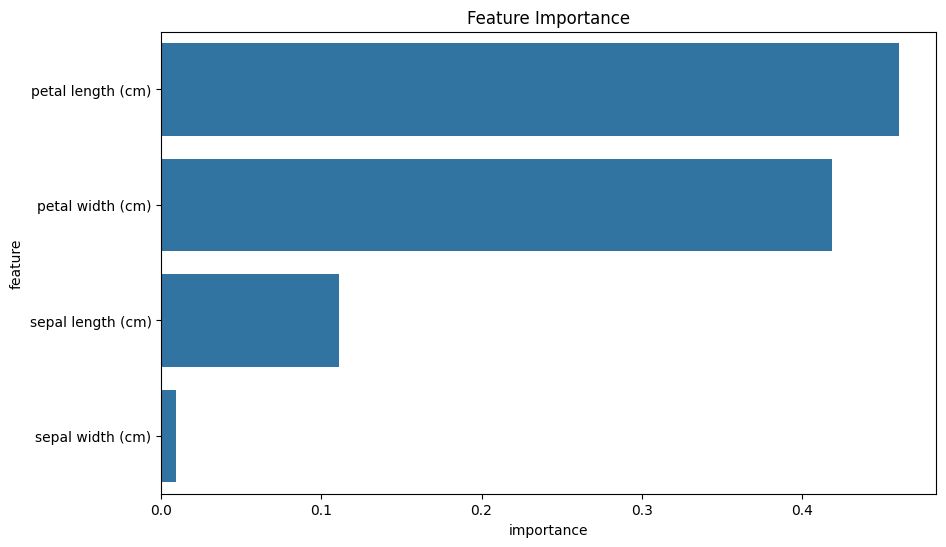

In [6]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns  # Confusion matrix 시각화를 위해 추가

# 데이터 로드
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Pandas DataFrame 생성
df = pd.DataFrame(data=X, columns=feature_names)
df['target'] = y
df['target_names'] = [target_names[i] for i in y]

# 데이터 프레임 출력 
print("DataFrame Sample :")
print(df.head())

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Random Foest 모델 생성
# 하이퍼파라미터 튜닝을 위해 GridSearchCV 사용
param_grid = {
    'n_estimators': [100, 200, 300], # 트리의 개수
    'max_depth': [4,6,8], # 트리의 최대 깊이
    'min_samples_split': [2, 5, 10], # 노드를 분할라기 위한 최소 샘플 수
    'min_samples_leaf': [1, 2, 4] # 리프 노드에 있어야 하는 최소 샘플 수
}

rf_model = RandomForestClassifier(random_state=42) # Random Forest 모델 초기화
# 교차 검증 cv = 3 : 훈련 데이터를 3개의 FOLD(묶음)으로 나누우서 두개를 훈려, 나머지는 검증 용도로 활용
# 교차 검증은 최적의 하이퍼 파리머터 값을 찾기 위해서 사용됨
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)

# 모델 학슴 (GridSearchCV를 통한 최적의 파라미터를 반영한 학습)
grid_search.fit(X_train, y_train)

# 최적의 파라미터 출력
print("최적의 파라미터 :", grid_search.best_params_)

# 최적의 모델 저장
best_rf_model = grid_search.best_estimator_

# 테스트 데이터로 예측 (하이퍼 파라미터 튜닝을 통해 최적화된 상태로 예측이 이루어짐)
y_pred = best_rf_model.predict(X_test)

# 정확도 평가
accuracy = accuracy_score(y_test, y_pred)
print(f"테스트 데이터 정확도 : {accuracy}")

# 분류 보고서
print("분류 보고서 :")
print(classification_report(y_test, y_pred, target_names=target_names))

# 혼동 행렬 (Confusion Matrix) 시각화
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
# annot = True : 혼동 행렬의 값을 표시 , fmt="d" : 정수로 표시, cmap="Blues" : 색상값은 블루
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Feature Importance 시각화
feature_importances = best_rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feature_importance_df)
plt.title("Feature Importance")
plt.show()


In [7]:
# 스팸 분류 예제

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer # 텍스트 데이터를 숫자로 변환 (TF-IDF 벡터화)
from sklearn.naive_bayes import MultinomialNB # 나이브 베이즈 분류기
from sklearn.metrics import accuracy_score, classification_report

# 1. 데이터 불러오기
data = pd.read_csv('./dataset/spam.csv', encoding='ISO-8859-1' ) # encoding 방식 : utf-8 (범용성)

# 데이터 내용 미리보기 
print("Spam Data (First 5 rows) :")
print(data.head())
print("\n")

data = data[['v1', 'v2']] # 불필요한 열 제거 
data.columns = ['label','text'] # 열 이름 변경

# 2. 데이터 전처리
data['label'] = data['label'].map({'ham':0, 'spam':1}) # 레이블을 숫자로 변환, map 함수 : 열의 각 값을 다른 값으로 변환하는 데사용
data.dropna(inplace=True) # 결측치 제거

# 3. 학습 및 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(data['text'], data['label'], test_size=0.2, random_state=42)

# 4. TF-IDF 벡터화
vectorizer = TfidfVectorizer(stop_words='english') # stop_words : 불필요한 영어 단어
X_train_tfidf = vectorizer.fit_transform(X_train) # fit : 학습 데이터의 중요한 통께정보 학습, transform : 숫자 벡터로 변환
X_test_tfidf = vectorizer.transform(X_test)

# 5. 모델 학습
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# 6. 예측 및 평가
y_pred = model.predict(X_test_tfidf)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Classification Report : " , classification_report(y_test, y_pred))

# 7. 샘플 테스트
sample_text = ["Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 now!",
               "Congratulations! You've been selected to receive a free iPhone 15. Click to claim now!",
               "Hey, are we meeting for lunch tomorrow?"]
sample_tfidf = vectorizer.transform(sample_text)
predictions = model.predict(sample_tfidf)
for text, label in zip(sample_text, predictions):
    print(f"Text : {text} => {'Spam' if label == 1 else 'Ham'}")
    

Spam Data (First 5 rows) :
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


Accuracy : 0.9668161434977578
Classification Report :                precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.75      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# 1. 데이터 불러오기
data = pd.read_csv('./dataset/spam.csv', encoding='ISO-8859-1')
data = data[['v1', 'v2']] # 필요한 열만 선택
data.columns = ['label', 'text'] # 열 이름 변경 

# 2. 데이터 전처리
data['label'] = data['label'].map({'ham':0, 'spam':1}) # 레이블을 숫자로 변환
data.dropna(inplace=True) # 결측치 제거

# 3. 학습 및 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(data['text'], data['label'], test_size=0.2, random_state=42)

# 4. TF-IDF 벡터화
vectorizer = TfidfVectorizer(stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# 5. 모델 학습
model = SVC(kernel='linear', random_state=42)
model.fit(X_train_tfidf, y_train)

# 6. 예측 및 평가
y_pred = model.predict(X_test_tfidf)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Classification Report :", classification_report(y_test, y_pred))

# 7. 샘플 테스트
sample_text = ["Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 now!",
               "Congratulations! You've been selected to receive a free iPhone 15. Click to claim now!",
               "Hey, are we meeting for lunch tomorrow?"]
sample_tfidf = vectorizer.transform(sample_text)
predictions = model.predict(sample_tfidf)
for text, label in zip(sample_text, predictions):
    print(f"Text : {text} => {'Spam' if label == 1 else 'Ham'}")

    




Accuracy : 0.979372197309417
Classification Report :               precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.97      0.87      0.92       150

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115

Text : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 now! => Spam
Text : Congratulations! You've been selected to receive a free iPhone 15. Click to claim now! => Spam
Text : Hey, are we meeting for lunch tomorrow? => Ham
